# ControlPlane — cascade economics

Can you tell, **before** a language model writes a single token, whether the answer
it is about to give will be wrong?

If you can, monitoring gets much cheaper. Serious checkers — LLM-as-judge, semantic
entropy, claim attribution — cost 200–1000 ms per call, so nobody runs them on all
their traffic. They sample a few percent; the rest ships unchecked.

This notebook displays what `scripts/run_all.py` measured. **It contains no logic**:
every number is read from `results/*.json`, and every table is built by a function in
`src/report.py` that is covered by the test suite. Nothing here is computed for display.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Jupyter sets the working directory to the notebook's own folder, but the
# paths in config.yaml are relative to the repo root. Without this chdir,
# results/ resolves to notebooks/results/ and every artifact appears missing.
os.chdir(REPO_ROOT)

from IPython.display import Image, Markdown, display

from src.config import load_config
from src.report import (
    headline_markdown,
    latency_frame,
    load_artifacts,
    metadata_frame,
    policy_frame,
    sweep_frame,
    test_metrics_frame,
)

config = load_config(REPO_ROOT / "config.yaml")
artifacts = load_artifacts(config)
results_dir = REPO_ROOT / config.paths.results_dir
print(f"loaded {len(artifacts)} artifacts from {results_dir}")

loaded 7 artifacts from C:\Users\LawLight\Desktop\accenture\results


## 1. What was run

The left-padding equivalence check is the load-bearing one. With right padding, position
`-1` of a padded batch is a pad token, every extracted activation is meaningless, and
nothing raises — the pipeline completes and returns an AUROC near 0.5 that reads as
"the idea doesn't work".

In [2]:
metadata_frame(artifacts)

,Value
Field,
Model,Qwen/Qwen2.5-7B-Instruct
Quantisation,nf4 (bfloat16)
Device,Tesla T4
Dataset,mandarjoshi/trivia_qa / rc.nocontext / validation
Examples,"3,000"
Split sizes,"train 1,800 · val 600 · test 600"
Seed,1729
Config hash,c429ce5e92da9a22
Git commit,6a77b3e4aa5c


## 2. Where in the stack the signal lives

Validation AUROC for every layer and every regularisation strength tried. **The layer was
chosen here, on validation.** Test played no part in the choice; every scoring of it is
logged and disclosed.

A smooth curve peaking mid-stack is itself evidence the signal is real rather than noise,
which is why the whole table is shown and not just the winner.

In [3]:
sweep_frame(artifacts)

C,0.000001,0.000010,0.000100,0.001000,0.010000,0.100000,1.000000
layer,,,,,,,
8,0.6690,0.7004,0.7360,0.7330,0.7096,0.6893,0.6806
11,0.6948,0.7339,0.7703,0.7659,0.7285,0.6985,0.6888
14,0.7193,0.7602,0.8028,0.8080,0.7764,0.7438,0.7306
17,0.7751,0.7962,0.8191,0.8140,0.7712,0.7255,0.7073
20,0.8005,0.8167,0.8380,0.8344,0.8054,0.7781,0.7675
23,0.8048,0.8198,0.8425,0.8377,0.7971,0.7671,0.7552
26,0.7946,0.8034,0.8263,0.8258,0.7956,0.7752,0.7636


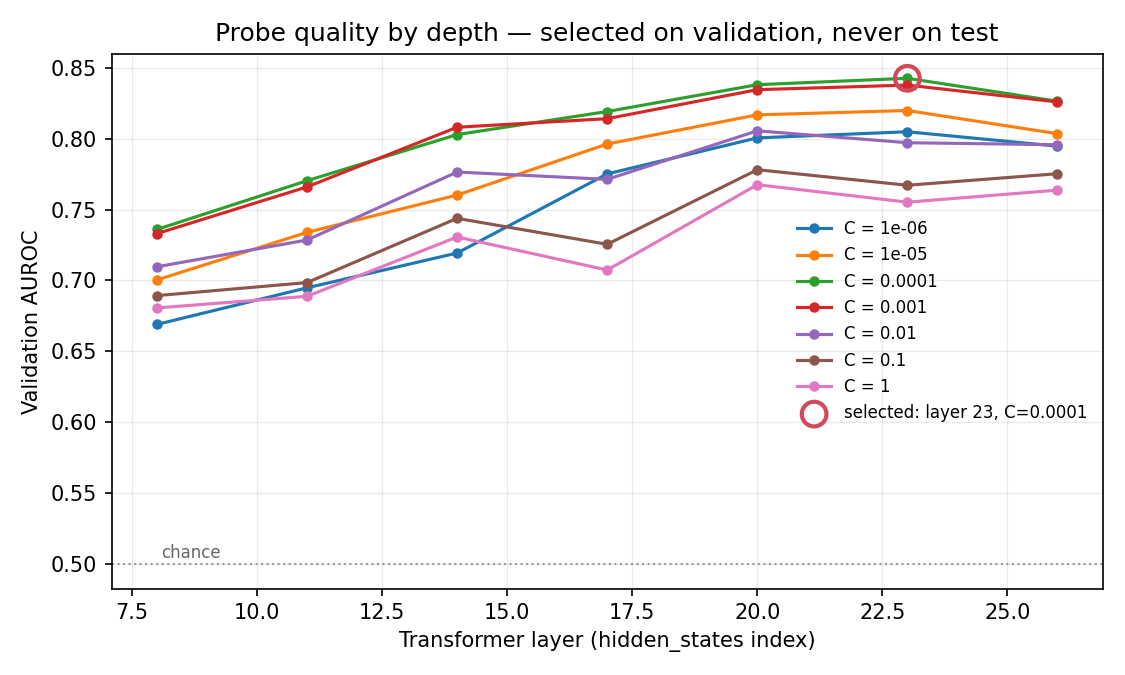

In [4]:
display(Image(filename=str(results_dir / "layer_sweep.png")))

## 3. Test results

Precision and recall are reported separately and never blended into an F1. The two failure
modes differ in cost by orders of magnitude: a false positive wastes one judge call, a
false negative lets a user act on a wrong answer. The probe is tuned for recall and low
precision is accepted by design.

In [5]:
test_metrics_frame(artifacts)

,Value,95% CI
Metric,,
AUROC,0.8551,"[0.8217, 0.8878]"
Measured flag rate f,0.0617,"[0.0433, 0.0817]"
Recall R,0.1416,"[0.1004, 0.1865]"
Precision,0.8919,"[0.7838, 0.9756]"
Base error rate,0.3883,—
Test examples,600,—


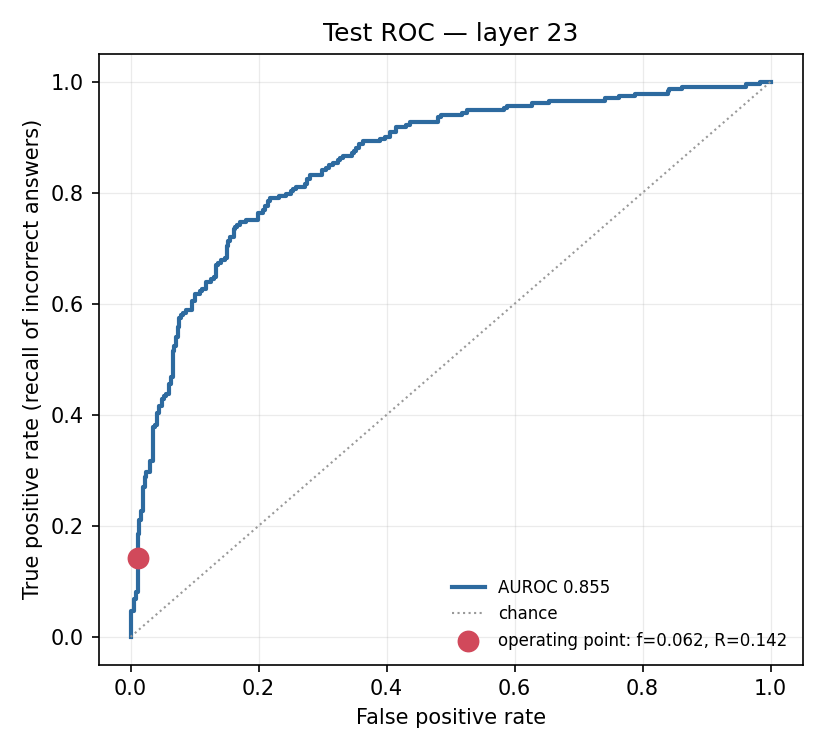

In [6]:
display(Image(filename=str(results_dir / "roc_curve.png")))

## 4. The three policies

All at N = 1,000,000 responses. Rows two and three spend **the same judge budget**.

Coverage and verdict are different things. Every response is scored by the probe; only the
expensive verdict is rationed. Random sampling has a few percent coverage *and* a few
percent verdict. That gap is the whole result.

In [7]:
policy_frame(artifacts)

,Judge calls,Coverage,Errors caught,Relative cost
Policy,,,,
Judge everything,"1,000,000",100%,"30,000",16x
Random 6.2% sample,"61,667",6.16667%,"1,850",1x
Probe-triggered,"61,667",100%,"4,249",1x


## 5. The headline

In [8]:
display(Markdown(headline_markdown(artifacts)))

# lift = R / f = 2.30x

### 95% CI [2.02, 2.63]

Measured on 600 held-out questions: recall **R = 0.142**, measured flag rate **f = 0.062**.

At the same judge budget as random sampling, the probe surfaces **2.30x** as many wrong answers.

`R/f` is independent of the base error rate and of the judge's own accuracy — both appear in every policy and cancel from the ratio.

## 6. Does it slow the model down?

No, and this is measured rather than claimed. The probe adds **no additional forward
pass**: the activation it reads is a by-product of the prefill that generation already
performs, so its marginal cost is one scale-and-dot-product.

In [9]:
latency_frame(artifacts)

,Value
Measurement,
Probe score (median),228.7 µs
Probe score (p95),315.1 µs
Generation (median/response),2557.3 ms
Prefill (median/response),351.4 ms
Probe / generation,8.94e-05
Additional forward passes,0 — the activation is a prefill by-product
Device,Tesla T4


## 7. What this does not show

The full limitations section is in [`results/RESULTS.md`](../results/RESULTS.md), written
from the artifacts rather than from boilerplate. The short version: one model, one dataset,
knowledge questions only, a single seed, and automatic alias matching standing in for human
judgment. This measures the probe, not an end-to-end system.

In [10]:
display(Markdown((results_dir / "RESULTS.md").read_text(encoding="utf-8")))

# RESULTS

Generated by `scripts/05_report.py`. Every number below is read from a JSON artifact in this directory; none is hand-entered.

## 1. Run metadata

| Field | Value |
|---|---|
| Model | `Qwen/Qwen2.5-7B-Instruct` |
| Quantisation | nf4 (bfloat16 compute) |
| Device | Tesla T4 |
| Seed | 1729 |
| Config hash | `c429ce5e92da9a22` |
| Git commit | `6a77b3e4aa5c5abd2b84a07dad777814ae65a39b` |
| Working tree dirty at run time | True |
| Timestamp (UTC) | 2026-08-22T02:13:15+00:00 |
| torch / transformers | 2.10.0+cu128 / 5.0.0 |

Left-padding equivalence check: relative L2 error **1.556e-02** (limit 1e-01), cosine similarity **0.999880** (limit 0.9990), across 4 prompts spanning the length distribution. Batched and unbatched last-token activations agree, so position -1 is the true final prompt token and not a pad token (CLAUDE.md invariant 4).

Positive control: repeating the same comparison with the tokenizer deliberately **right**-padded gives relative L2 1.278e+00 and cosine 0.1414 — rejected, as it must be. The check is therefore demonstrated to discriminate a real padding fault on this model and this hardware, not merely to have passed.

## 2. Dataset

| Field | Value |
|---|---|
| Source | `mandarjoshi/trivia_qa`, config `rc.nocontext`, split `validation` |
| Rows loaded | 17,944 |
| Dropped as duplicate questions | 7,983 |
| Dropped as empty or aliasless | 0 |
| Sampled | 3,000 |
| Split sizes | train 1,800 / val 600 / test 600 |
| Accuracy (lenient alias match) | 0.594 |
| Accuracy (strict exact match) | 0.106 |
| **Base error rate (positive class)** | **0.406** |

Splits are by `question_id` after deduplicating normalised question strings, and are asserted pairwise disjoint on both keys (CLAUDE.md invariant 3).

**Labelling note.** Lenient and strict matching disagree by 0.488 in accuracy, more than the ~10 point threshold SPEC.md §2 asks to be called out. The lenient rule is primary (DECISIONS.md 007); the gap is the amount of correctness attributable to a gold alias appearing inside a longer sentence.

## 3. Layer sweep — validation AUROC

| Layer | C=1e-06 | C=1e-05 | C=0.0001 | C=0.001 | C=0.01 | C=0.1 | C=1 |
|---|---|---|---|---|---|---|---|
| 8 | 0.6690 | 0.7004 | 0.7360 | 0.7330 | 0.7096 | 0.6893 | 0.6806 |
| 11 | 0.6948 | 0.7339 | 0.7703 | 0.7659 | 0.7285 | 0.6985 | 0.6888 |
| 14 | 0.7193 | 0.7602 | 0.8028 | 0.8080 | 0.7764 | 0.7438 | 0.7306 |
| 17 | 0.7751 | 0.7962 | 0.8191 | 0.8140 | 0.7712 | 0.7255 | 0.7073 |
| 20 | 0.8005 | 0.8167 | 0.8380 | 0.8344 | 0.8054 | 0.7781 | 0.7675 |
| 23 | 0.8048 | 0.8198 | **0.8425** | 0.8377 | 0.7971 | 0.7671 | 0.7552 |
| 26 | 0.7946 | 0.8034 | 0.8263 | 0.8258 | 0.7956 | 0.7752 | 0.7636 |

**Selected: layer 23 of 28, C = 0.0001**, on validation AUROC 0.8425. The layer, the regularisation strength and the threshold were all chosen here, on validation. Test played no part in the selection (CLAUDE.md invariant 2); every scoring of it is disclosed in the next section.

![Layer sweep](layer_sweep.png)

## 4. Test results

**The test set has been scored 2 times**, at n = 600. Disclosed rather than claimed: every scoring is appended to `results/test_scoring_log.json` and reproduced below. Each selection that produced one was made on validation alone (DECISIONS.md 016).

The log begins when it was introduced, so any scoring that predates it is recorded in `DECISIONS.md` 016 and 017 rather than in the table below. Treat the two together as the full history.

| # | Layer | C | AUROC | `f` | `R` | Lift | Config hash |
|---|---|---|---|---|---|---|---|
| 1 | 23 | 0.0001 | 0.8551 | 0.0617 | 0.1416 | 2.30x | `c429ce5e92da9a22` |
| 2 | 23 | 0.0001 | 0.8551 | 0.0617 | 0.1416 | 2.30x | `c429ce5e92da9a22` |

| Metric | Value | 95% CI |
|---|---|---|
| AUROC | 0.8551 | [0.8217, 0.8878] |
| Measured flag rate `f` | 0.0617 | [0.0433, 0.0817] |
| Recall `R` | 0.1416 | [0.1004, 0.1865] |
| Precision | 0.8919 | [0.7838, 0.9756] |
| Base error rate | 0.3883 | — |

Confusion at the frozen threshold (1.5881): TP 33, FP 4, FN 200, TN 363. 37 of 600 responses flagged; 233 were incorrect.

Precision and recall are reported separately and never blended (CLAUDE.md invariant 5). Low precision is by design: a false positive costs one wasted judge call, a false negative costs a user acting on a wrong answer (DECISIONS.md 005).

The threshold was chosen on validation to hit a flag rate of 0.050 and achieved 0.050 there. On test the measured rate is 0.0617, and **that measured value is what every calculation below uses** (CLAUDE.md invariant 6).

![Test ROC](roc_curve.png)

## 5. Three policies at N = 1,000,000

Assumed base error rate 0.030 (illustrative), judge accuracy 1.00.

| Policy | Judge calls | Responses seen by any check | Errors caught | Relative cost |
|---|---|---|---|---|
| Judge everything | 1,000,000 | 100% | 30,000 | 16x |
| Random 6.2% sample | 61,667 | 6.16667% | 1,850 | 1x |
| **Probe-triggered** | **61,667** | **100%** | **4,249** | **1x** |

Coverage and verdict are different things. Every response passes the cheap probe; only the expensive verdict is rationed. Random sampling has 6.2% coverage *and* 6.2% verdict. That gap is the result.

> **The 'errors caught' column mixes two regimes.** It applies the recall measured at a base error rate of 0.3883 to an assumed production rate of 0.030. The **ratio** between the rows is unaffected — that is the point of `lift`, and both the assumed rate and judge accuracy cancel from it. The **absolute counts** are conservative: at the lower assumed rate the same probe would reach a higher recall (see the projection below), so the probe-triggered row understates rather than overstates.

## 6. Headline — lift

### lift = R / f = 2.30x [2.02, 2.63]

At the same judge budget as random sampling, the probe surfaces **2.30x** as many wrong answers.

**The base error rate assumed in the policy table, and the judge's accuracy, both cancel from the ratio.** They appear in every policy's errors-caught figure, so the multiplier does not rest on an assumption about how often the model is wrong in production or about how good the judge is.

**But the measured lift is bounded by the base rate of the set it was measured on**, and that is a different statement. Algebraically `lift = R/f = precision / base_rate`, so precision <= 1 caps lift at `1 / base_rate` = **2.58x** on this test set, whose base error rate is 0.3883. The measured 2.30x is **89.2% of everything that was attainable here.** No probe, however well it ranks, could have scored much higher on this dataset (DECISIONS.md 015).

Checked both ways: `R/f` = 2.2967 and `precision/base_rate` = 2.2967.

The ceiling is itself an estimate: [2.35, 2.86] over the same bootstrap resamples. A resample drawing fewer incorrect answers has a higher ceiling, which is why the interval on lift ([2.02, 2.63]) can reach above the 2.58x computed from the point base rate. Within any single resample the two cannot cross: `lift / ceiling` is precision, which is at most 1.

#### Headroom at lower base error rates — a projection, not a result

A ROC curve is base-rate independent: it describes how well the probe *ranks*, which is a property of the probe rather than of how often the model is wrong. So the measured curve can be re-read at other base error rates, holding the budget at the measured `f` = 0.0617.

| Base error rate | Budget `f` | Recall `R` | Lift | Ceiling (1/base rate) |
|---|---|---|---|---|
| 0.100 | 0.0587 | 0.3176 | 5.41x | 10.0x |
| 0.050 | 0.0616 | 0.4034 | 6.55x | 20.0x |
| 0.030 | 0.0605 | 0.4292 | 7.10x | 33.3x |
| 0.010 | 0.0583 | 0.4378 | 7.51x | 100.0x |

> **PROJECTION, NOT MEASUREMENT. A ROC is base-rate independent, so the measured curve can be read at another base error rate. This assumes the probe ranks equally well on that workload -- the cross-domain generalisation this repo has NOT tested. Treat as an illustration of headroom, never as a result.**

Demonstrated, not asserted: recomputing the table across error rates [0.01, 0.03, 0.1, 0.5] and judge accuracies [0.5, 0.8, 1.0] gives 12 lifts with a spread of 8.9e-16 (all equal: True).

The interval is a 95% percentile bootstrap over 1,000 resamples of the 600 test examples, resampling recall and flag rate jointly because lift is their ratio.

## 7. Latency

| Measurement | Value |
|---|---|
| Probe score, median (full scikit-learn call) | 228.7 µs |
| Probe score, p95 | 315.1 µs |
| — of which arithmetic (standardise + dot + bias) | 7.7 µs |
| Generation, median per response | 2557.3 ms |
| Prefill, median per response | 351.4 ms |
| Probe / generation | 8.94e-05 |
| Probe / prefill | 6.51e-04 |
| Device | Tesla T4 |
| torch | 2.10.0+cu128 |
| Quantisation | nf4 |

**The probe adds no additional forward pass.** The activation is a by-product of the prefill that generation already performs, so its marginal cost is the scale-and-dot-product timed above and nothing else.

The headline figure is the whole scikit-learn call. Most of it is input validation and array copying, not arithmetic: the dot product itself is 29.8x faster. The slower, deployable number is quoted as the headline on purpose.

Extraction throughput for reference: 3,000 examples in 2h 19m (0.36 examples/s) at batch size 8.

## 8. Secondary validation — abstention correlation

Abstention rate on test is 0.0000 (0 of 600), below the 0.02 floor. **The comparison is underpowered and is not reported as a result** (SPEC.md §9).

## 9. Negative control — reproducing a documented limitation

Not run — **and not implemented in this build**. The published result reports that probe generalisation falters on mathematical reasoning (DECISIONS.md 008), and reproducing that on GSM8K is Stage 6 of `TASKS.md`: an optional stage that requires a completed main run first. The `negative_control` block in `config.yaml` reserves the settings for it, but no code reads them yet, so setting `enabled: true` does nothing today. Until Stage 6 is built and run, cross-domain generalisation is untested here and is listed as a limitation below.

## 10. Limitations

- **The headline lift is bounded by this benchmark, not by the probe.** `lift = precision / base_rate`, so a base error rate of 0.3883 caps it at 2.58x however well the probe ranks. The measured value reaches 89.2% of that. The transferable quantity is the AUROC; the lift is specific to a workload where the model is wrong this often (DECISIONS.md 015).
- **One model, one dataset.** `Qwen/Qwen2.5-7B-Instruct` on mandarjoshi/trivia_qa (rc.nocontext). Cross-model and cross-dataset generalisation is untested here.
- **Knowledge questions only.** The published result reports that generalisation falters on mathematical reasoning; the GSM8K control was not run, so that boundary is cited here rather than measured.
- **This measures the probe, not a system.** There is no gateway, no serving path, and no end-to-end latency under load. The latency figures are component measurements taken in isolation.
- **`f` depends on workload.** The flag rate of 0.0617 is for this dataset at this threshold. Real traffic has a different difficulty distribution and would produce a different rate at the same threshold.
- **Judge accuracy is assumed to cancel.** It does cancel from the ratio, but a real judge misses errors the probe correctly flagged, so the absolute errors-caught counts in the three-policy table are upper bounds.
- **Single seed.** Everything reported is at seed 1729. No seed sweep was run, so the intervals reflect test-set sampling only, not variation in the split or in probe fitting.
- **Labelling is automatic.** Normalised alias matching is a proxy for correctness, not human judgment. Lenient and strict matching differ by 0.488 in accuracy here.
- **Test set is small.** 600 examples, which is why every headline number carries a bootstrap interval rather than a point estimate alone.

